# Schrödinger Bridges via Conic Optimization

**Entropy-regularized optimal transport is a Schrödinger bridge.**

This notebook demonstrates:
- The **Schrödinger bridge** — entropy-regularized OT connects directly to diffusion models
- **Particle trajectories** as Brownian bridges: straight paths at low ε, random walks at high ε
- **Unbalanced OT** with KL penalties on marginals — mass creation/destruction via exponential cones
- **Noise → data** distributions mirror the generative modeling setup
- **cvxpylayers** wraps each formulation as a differentiable PyTorch layer — parameters
  like ε and ρ become batch dimensions, solved in a single call

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore", message="First solve is benchmarking")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="numpy")

import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import torch
from cvxpylayers.torch import CvxpyLayer

from utils.style import (
    set_moreau_style, set_moreau_dark_style,
    MOREAU_COLORS,
)
from utils.animation import fig_to_pil, save_gif, display_gif

set_moreau_style()
np.random.seed(42)

## Noise → Data

Source is a broad Gaussian (noise), target is three sharp peaks (structured data).
This mirrors the generative modeling setup: how does noise concentrate into data?

Bins:       100
Source sum: 1.000000
Target sum: 1.000000
Cost range: [0.0000, 1.0000]


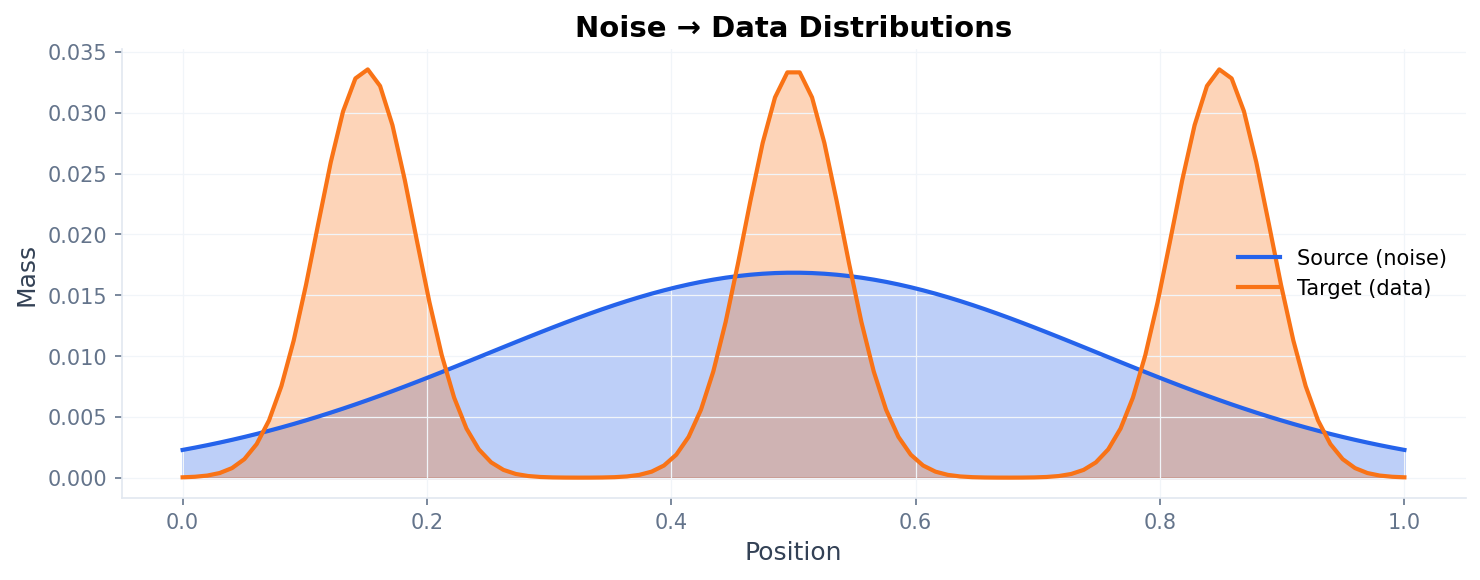

In [2]:
n_bins = 100
x = np.linspace(0, 1, n_bins)

def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Source: broad noise
source_dist = gaussian(x, 0.5, 0.25)
# Target: three sharp data peaks
target_dist = gaussian(x, 0.15, 0.04) + gaussian(x, 0.5, 0.04) + gaussian(x, 0.85, 0.04)

# Normalize to sum to 1
a = source_dist / source_dist.sum()
b_marg = target_dist / target_dist.sum()

# Cost matrix: squared distance
C = (x[:, None] - x[None, :]) ** 2

print(f"Bins:       {n_bins}")
print(f"Source sum: {a.sum():.6f}")
print(f"Target sum: {b_marg.sum():.6f}")
print(f"Cost range: [{C.min():.4f}, {C.max():.4f}]")

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(x, a, alpha=0.3, color=MOREAU_COLORS["primary"])
ax.plot(x, a, color=MOREAU_COLORS["primary"], linewidth=2, label="Source (noise)")
ax.fill_between(x, b_marg, alpha=0.3, color=MOREAU_COLORS["accent"])
ax.plot(x, b_marg, color=MOREAU_COLORS["accent"], linewidth=2, label="Target (data)")
ax.set_xlabel("Position")
ax.set_ylabel("Mass")
ax.set_title("Noise → Data Distributions")
ax.legend()
plt.tight_layout()
plt.show()

## Balanced Schrödinger Bridge

Entropy-regularized OT is a Schrödinger bridge — it finds the most likely stochastic process
connecting two distributions, given a noise level ε:

$$\min_{T \ge 0}\; \sum_{ij} C_{ij}\, T_{ij} \;+\; \varepsilon \sum_{ij} T_{ij} \log T_{ij}
\quad\text{s.t.}\quad \sum_j T_{ij} = a_i,\;\; \sum_i T_{ij} = b_j$$

The parameter ε controls stochasticity:
- **ε → 0**: deterministic optimal transport (straight paths)
- **Large ε**: maximum entropy (Brownian motion between distributions)

CVXPY's `cp.entr(T)` computes $-T \log T$ elementwise, which it reduces to
**exponential cone** constraints under the hood. Wrapping the problem in a
`CvxpyLayer` with ε as a parameter lets us solve multiple noise levels in one call.

In [3]:
# Parametric balanced OT: ε is the parameter
eps_param = cp.Parameter(nonneg=True)
T_bal_var = cp.Variable((n_bins, n_bins), nonneg=True)
cost = cp.sum(cp.multiply(C, T_bal_var))
entropy = cp.sum(cp.entr(T_bal_var))
prob_bal = cp.Problem(
    cp.Minimize(cost - eps_param * entropy),
    [cp.sum(T_bal_var, axis=1) == a, cp.sum(T_bal_var, axis=0) == b_marg],
)

balanced_layer = CvxpyLayer(
    prob_bal, parameters=[eps_param], variables=[T_bal_var], solver="MOREAU",
)

# Solve for 3 ε values in one batched call
epsilon_values = [0.001, 0.01, 0.1]
labels = ["ε ≈ 0 (deterministic)", "ε = 0.01 (bridge)", "ε = 0.1 (diffusion)"]

eps_batch = torch.tensor(epsilon_values, dtype=torch.float64)
with torch.no_grad():
    T_out, = balanced_layer(eps_batch)

T_results = {}
for i, (eps, label) in enumerate(zip(epsilon_values, labels)):
    T = T_out[i].numpy()
    T_results[eps] = T
    print(f"=== {label} ===")
    print(f"Row sums:   min={T.sum(1).min():.6f}  max={T.sum(1).max():.6f}")
    print(f"Col sums:   min={T.sum(0).min():.6f}  max={T.sum(0).max():.6f}")
    print()

=== ε ≈ 0 (deterministic) ===
Row sums:   min=0.002280  max=0.016846
Col sums:   min=0.000005  max=0.033558

=== ε = 0.01 (bridge) ===
Row sums:   min=0.002280  max=0.016846
Col sums:   min=0.000005  max=0.033558

=== ε = 0.1 (diffusion) ===
Row sums:   min=0.002280  max=0.016846
Col sums:   min=0.000005  max=0.033558



## Bridge Dynamics

Each entry $T_{ij}$ of the transport plan defines the probability of a particle traveling
from source position $x_i$ to target position $x_j$. Sampling from $T$ and drawing
**Brownian bridge** paths reveals the bridge dynamics:

$$x(t) = (1-t)\, x_i + t\, x_j + \sqrt{2\varepsilon}\, B(t)$$

where $B(t)$ is a standard Brownian bridge (zero at $t=0,1$; variance $t(1-t)$).

- **Low ε**: paths are straight lines (deterministic OT)
- **High ε**: paths wiggle like random walks (diffusion)

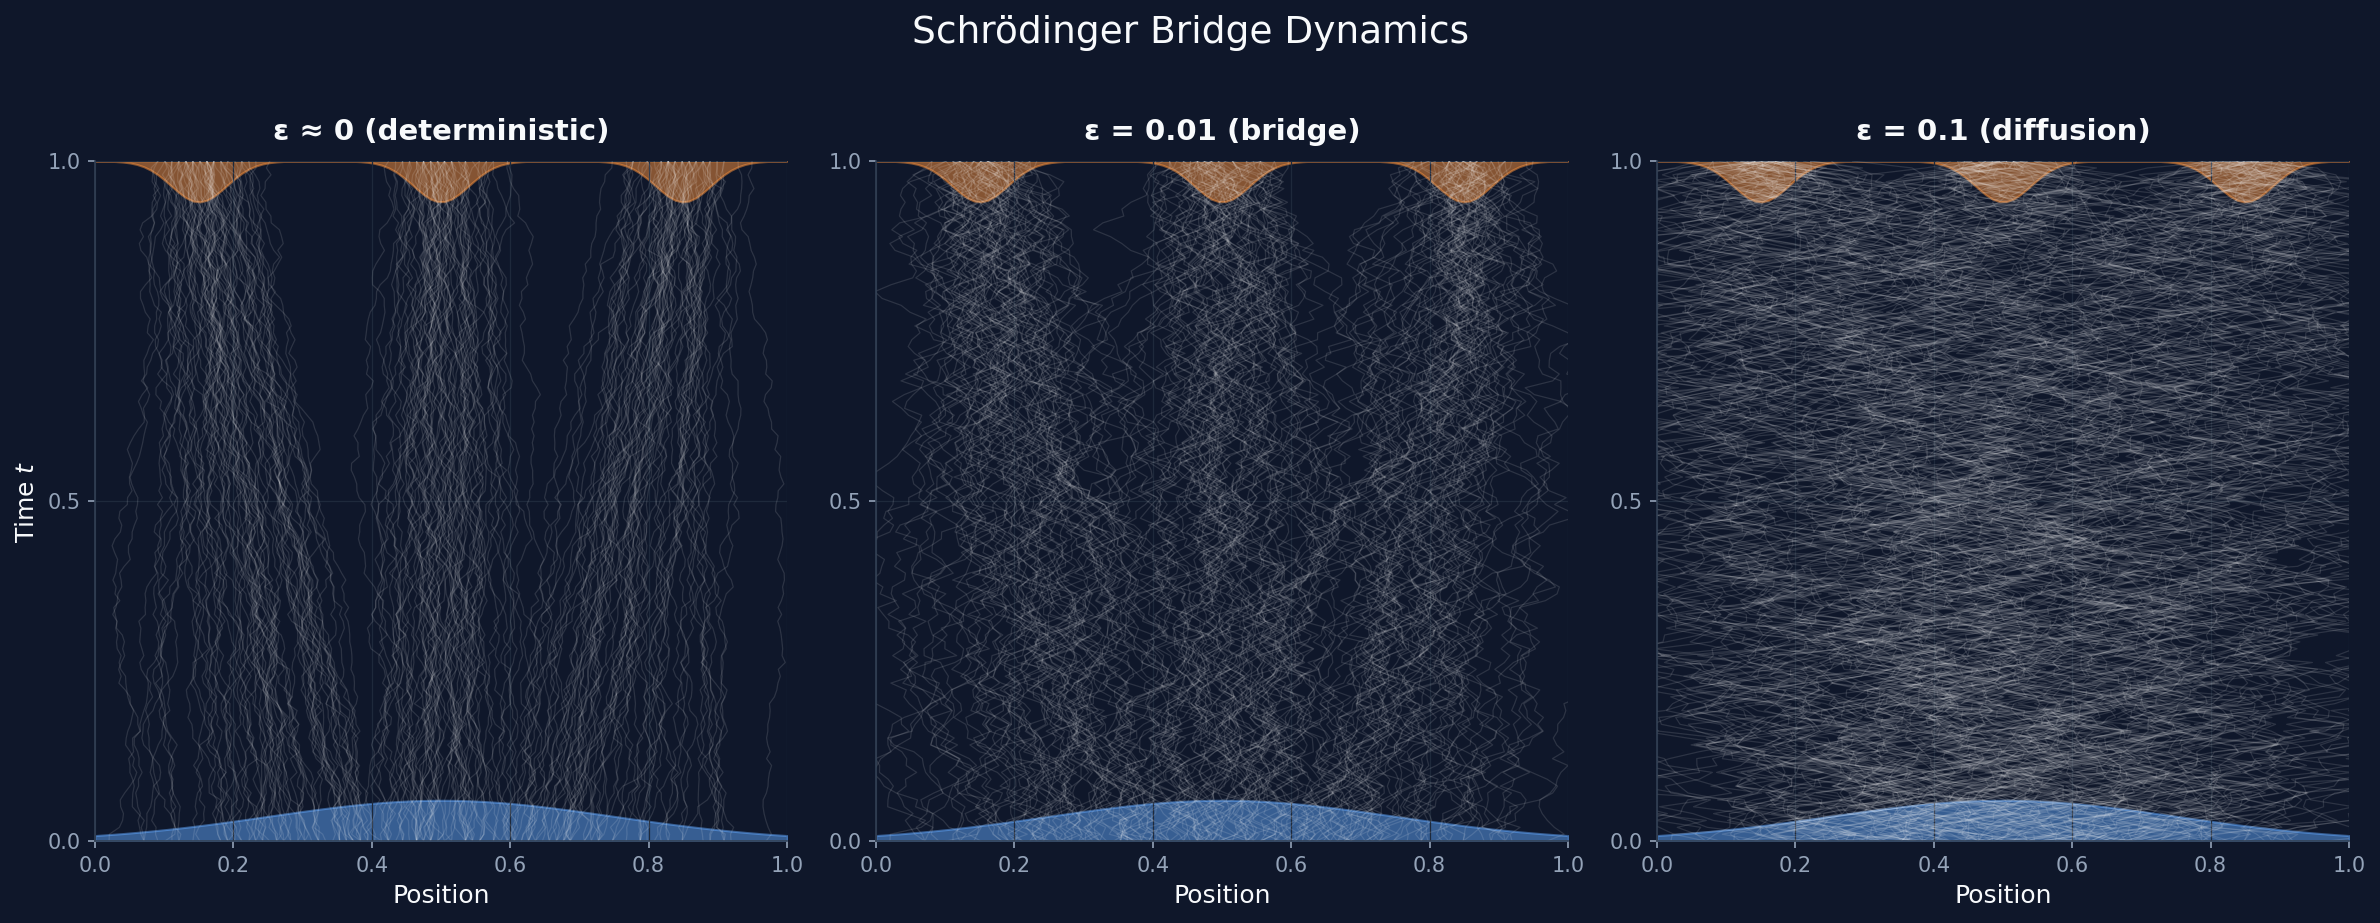

Saved assets/optimal_transport.png


In [4]:
def sample_bridge_paths(T, x_src, x_tgt, epsilon, n_paths=200, n_steps=100, seed=42):
    # Sample Brownian bridge paths from a transport plan.
    rng = np.random.default_rng(seed)
    probs = np.maximum(T.ravel(), 0)
    probs /= probs.sum()
    idx = rng.choice(len(probs), size=n_paths, p=probs)
    ii, jj = idx // len(x_tgt), idx % len(x_tgt)

    times = np.linspace(0, 1, n_steps)
    dt = times[1] - times[0]
    paths = np.zeros((n_paths, n_steps))

    for k in range(n_paths):
        mean = (1 - times) * x_src[ii[k]] + times * x_tgt[jj[k]]
        dW = rng.standard_normal(n_steps - 1) * np.sqrt(dt)
        W = np.concatenate([[0], np.cumsum(dW)])
        B = W - times * W[-1]
        paths[k] = mean + np.sqrt(2 * epsilon) * B

    return times, paths, ii, jj


set_moreau_dark_style()
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, eps, title in zip(axes, epsilon_values, labels):
    T = T_results[eps]
    times, paths, _, _ = sample_bridge_paths(T, x, x, eps, n_paths=200)

    for k in range(len(paths)):
        ax.plot(paths[k], times, color="white", alpha=0.12, linewidth=0.6)

    # Source distribution at bottom
    scale = 0.06
    a_scaled = a / a.max() * scale
    ax.fill_between(x, 0, a_scaled, color=MOREAU_COLORS["primary_light"], alpha=0.5)
    # Target distribution at top
    b_scaled = b_marg / b_marg.max() * scale
    ax.fill_between(x, 1 - b_scaled, 1, color=MOREAU_COLORS["accent_light"], alpha=0.5)

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel("Position")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])
    if ax is axes[0]:
        ax.set_ylabel("Time $t$")

fig.suptitle("Schrödinger Bridge Dynamics", fontsize=18, y=1.02,
             color=MOREAU_COLORS["text"])
plt.tight_layout()
plt.savefig("../assets/optimal_transport.png", bbox_inches="tight",
            facecolor=MOREAU_COLORS["bg_dark"])
plt.show()
print("Saved assets/optimal_transport.png")

## Unbalanced Bridges

In standard OT, marginals are exactly conserved: all source mass must reach the target.
**Unbalanced OT** relaxes this with KL penalties — mass can be created or destroyed,
modeling birth-death processes in diffusion.

$$\min_{T \ge 0}\; \sum_{ij} C_{ij} T_{ij} + \varepsilon \sum_{ij} T_{ij} \log T_{ij}
+ \rho\, \text{KL}(T\mathbf{1} \| a) + \rho\, \text{KL}(T^\top\mathbf{1} \| b)$$

where $\text{KL}(r \| a) = \sum_i \bigl[r_i \log(r_i / a_i) - r_i + a_i\bigr]$ is the
generalized KL divergence. We also add mass bounds $T\mathbf{1} \le a$, $T^\top\mathbf{1} \le b$
to prevent mass creation.

The parameter ρ controls mass conservation:
- **Large ρ** (≈100): effectively balanced, all mass transported
- **Small ρ** (≈0.001): highly unbalanced, only nearby mass moves

CVXPY's `cp.kl_div(r, a)` computes the generalized KL elementwise, adding more
exponential cone constraints to the conic program. We wrap the problem as a
`CvxpyLayer` with ρ as a parameter for easy sweeping.

In [5]:
eps_fixed = 0.001

# Parametric unbalanced OT: ρ is the parameter
rho_param = cp.Parameter(nonneg=True)
T_unb_var = cp.Variable((n_bins, n_bins), nonneg=True)
cost_u = cp.sum(cp.multiply(C, T_unb_var))
entropy_u = cp.sum(cp.entr(T_unb_var))
r = cp.sum(T_unb_var, axis=1)
c = cp.sum(T_unb_var, axis=0)
kl_row = cp.sum(cp.kl_div(r, a))
kl_col = cp.sum(cp.kl_div(c, b_marg))
prob_unb = cp.Problem(
    cp.Minimize(cost_u - eps_fixed * entropy_u + rho_param * (kl_row + kl_col)),
    [r <= a, c <= b_marg],
)

unbalanced_layer = CvxpyLayer(
    prob_unb, parameters=[rho_param], variables=[T_unb_var], solver="MOREAU",
)

# Solve balanced (ρ=100) vs unbalanced (ρ=0.001)
rho_compare = torch.tensor([100.0, 0.001], dtype=torch.float64)
with torch.no_grad():
    T_cmp, = unbalanced_layer(rho_compare)

T_bal = T_cmp[0].numpy()
T_unb = T_cmp[1].numpy()

for T, label in [(T_bal, "Balanced (ρ=100)"), (T_unb, "Unbalanced (ρ=0.001)")]:
    print(f"=== {label} ===")
    print(f"Transported mass: {np.maximum(T, 0).sum():.4f}")
    print(f"Row sums range:   [{T.sum(1).min():.6f}, {T.sum(1).max():.6f}]")
    print()

=== Balanced (ρ=100) ===
Transported mass: 0.9999
Row sums range:   [0.002280, 0.016842]

=== Unbalanced (ρ=0.001) ===
Transported mass: 0.6846
Row sums range:   [0.000306, 0.016846]



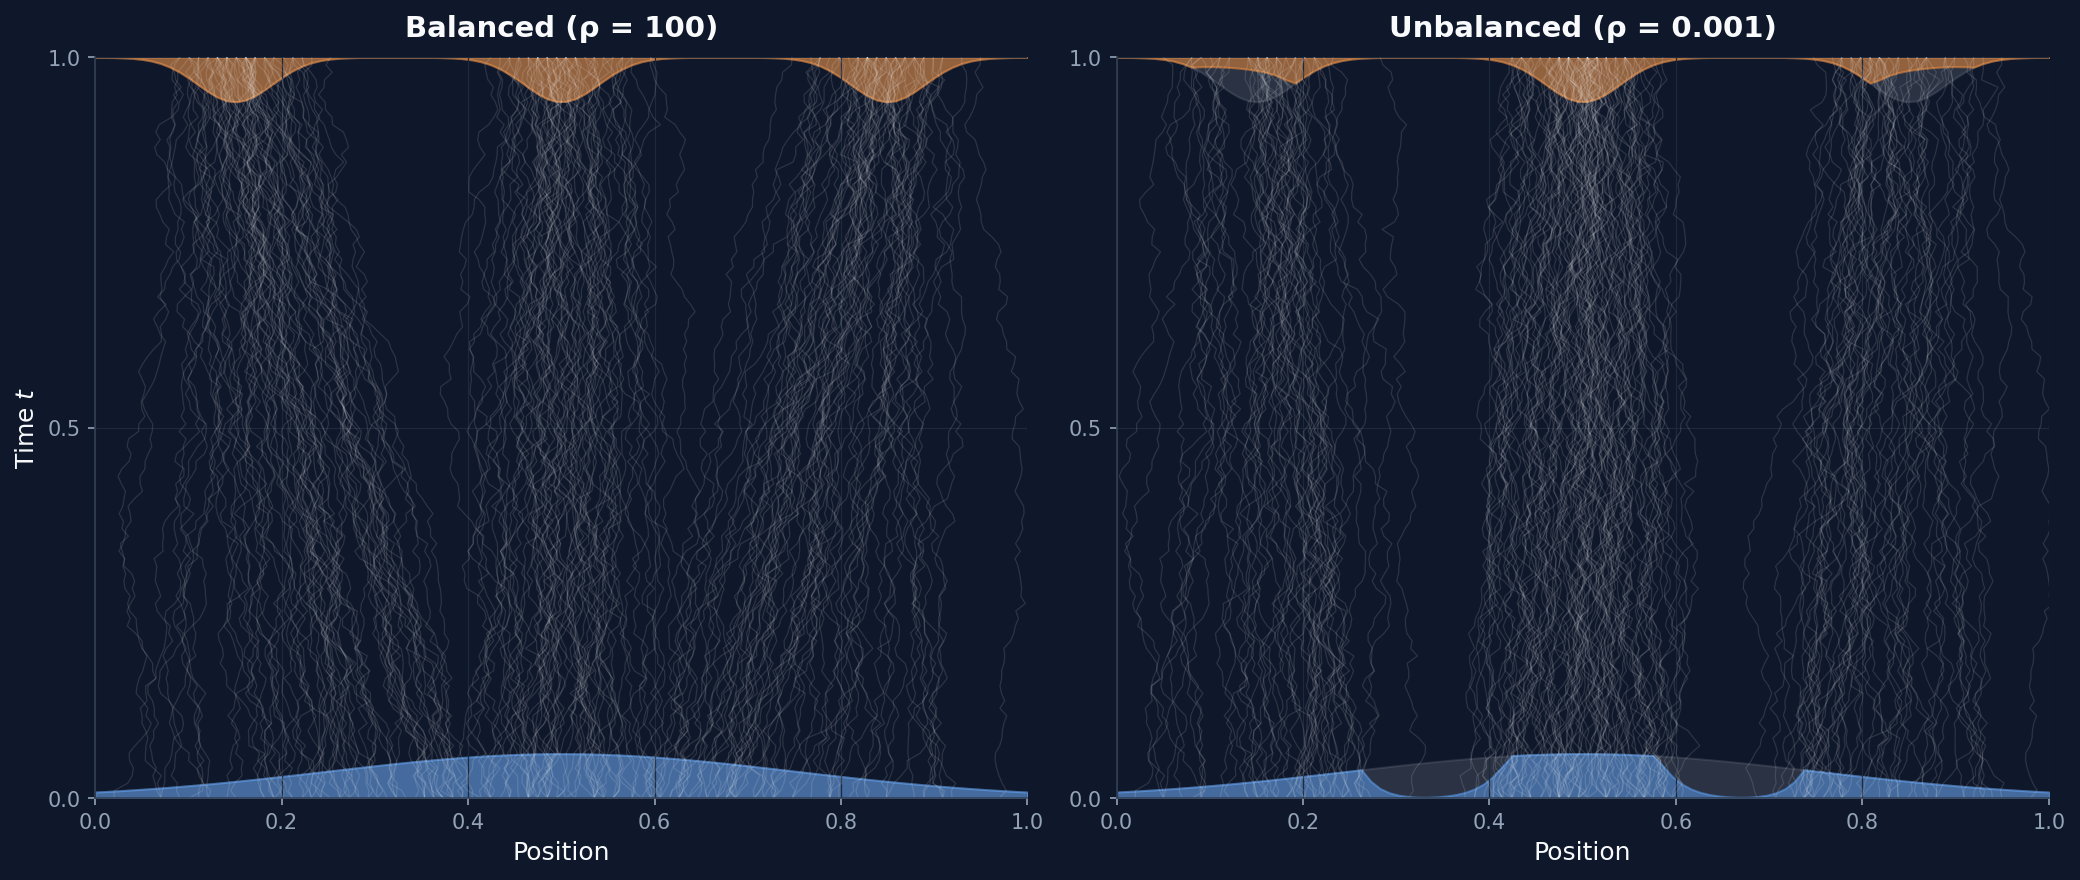

Saved assets/ot_sweep.png


In [6]:
set_moreau_dark_style()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, T, title in [
    (ax1, T_bal, "Balanced (ρ = 100)"),
    (ax2, T_unb, "Unbalanced (ρ = 0.001)"),
]:
    times, paths, _, _ = sample_bridge_paths(T, x, x, eps_fixed, n_paths=200)
    for k in range(len(paths)):
        ax.plot(paths[k], times, color="white", alpha=0.12, linewidth=0.6)

    # Row/col marginals
    r = np.maximum(T.sum(axis=1), 0)
    c = np.maximum(T.sum(axis=0), 0)

    scale = 0.06
    # Source: gray for full distribution, blue for transported
    a_scaled = a / a.max() * scale
    r_scaled = r / a.max() * scale
    ax.fill_between(x, 0, a_scaled, color=MOREAU_COLORS["neutral"], alpha=0.3)
    ax.fill_between(x, 0, r_scaled, color=MOREAU_COLORS["primary_light"], alpha=0.5)

    # Target: gray for full distribution, orange for received
    b_scaled = b_marg / b_marg.max() * scale
    c_scaled = c / b_marg.max() * scale
    ax.fill_between(x, 1 - b_scaled, 1, color=MOREAU_COLORS["neutral"], alpha=0.3)
    ax.fill_between(x, 1 - c_scaled, 1, color=MOREAU_COLORS["accent_light"], alpha=0.5)

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel("Position")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])

ax1.set_ylabel("Time $t$")

plt.tight_layout()
plt.savefig("../assets/ot_sweep.png", bbox_inches="tight",
            facecolor=MOREAU_COLORS["bg_dark"])
plt.show()
print("Saved assets/ot_sweep.png")

In the balanced case (left), all source mass reaches the target — row marginals
match the source exactly. In the unbalanced case (right), distant mass stays put:
only source regions near target peaks are transported.

## Mass Conservation Sweep

We reuse the same `unbalanced_layer` to sweep 64 values of ρ from balanced (100) to
highly unbalanced (0.001). The conic structure was compiled once when the layer was
created — each solve only updates the ρ-dependent terms in the objective.

In [7]:
n_batch = 64
rho_sweep = np.geomspace(100, 0.001, n_batch)
rho_batch = torch.tensor(rho_sweep, dtype=torch.float64)

with torch.no_grad():
    T_sweep, = unbalanced_layer(rho_batch)

Ts_batch = T_sweep.numpy()
mass_transported = np.array([np.maximum(Ts_batch[i], 0).sum() for i in range(n_batch)])

print(f"Solved: {n_batch}/{n_batch}")
print(f"Mass range: [{mass_transported.min():.4f}, {mass_transported.max():.4f}]")

Solved: 64/64
Mass range: [0.6846, 0.9999]


In [8]:
set_moreau_dark_style()

n_frames = 30
frame_indices = np.linspace(0, n_batch - 1, n_frames).astype(int)

# Fixed particle paths from balanced solution (first in batch, ρ=100)
T_ref = np.maximum(Ts_batch[0], 0)
times_ref, paths_ref, ii_ref, jj_ref = sample_bridge_paths(
    T_ref, x, x, eps_fixed, n_paths=200,
)

frames = []
for fi, bi in enumerate(frame_indices):
    fig, ax = plt.subplots(figsize=(8, 6))
    T_frame = np.maximum(Ts_batch[bi], 0)
    T_ref_vals = T_ref[ii_ref, jj_ref]
    T_frame_vals = T_frame[ii_ref, jj_ref]

    # Alpha proportional to mass ratio
    alpha_base = 0.15
    for k in range(len(paths_ref)):
        ratio = T_frame_vals[k] / max(T_ref_vals[k], 1e-30)
        alpha = alpha_base * min(ratio, 1.0)
        if alpha > 0.005:
            ax.plot(paths_ref[k], times_ref, color="white",
                    alpha=alpha, linewidth=0.6)

    # Source/target
    scale = 0.06
    ax.fill_between(x, 0, a / a.max() * scale,
                    color=MOREAU_COLORS["primary_light"], alpha=0.5)
    ax.fill_between(x, 1 - b_marg / b_marg.max() * scale, 1,
                    color=MOREAU_COLORS["accent_light"], alpha=0.5)

    ax.set_xlabel("Position")
    ax.set_ylabel("Time $t$")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])
    ax.set_title(
        f"ρ = {rho_sweep[bi]:.2f} (transported: {mass_transported[bi]:.0%})",
        fontsize=14, pad=10,
    )

    plt.tight_layout()
    frames.append(fig_to_pil(fig, dpi=100))
    plt.close(fig)

save_gif(frames, "../assets/ot_anim.gif", fps=8)
print(f"Saved {n_frames}-frame animation to assets/ot_anim.gif")

Saved 30-frame animation to assets/ot_anim.gif



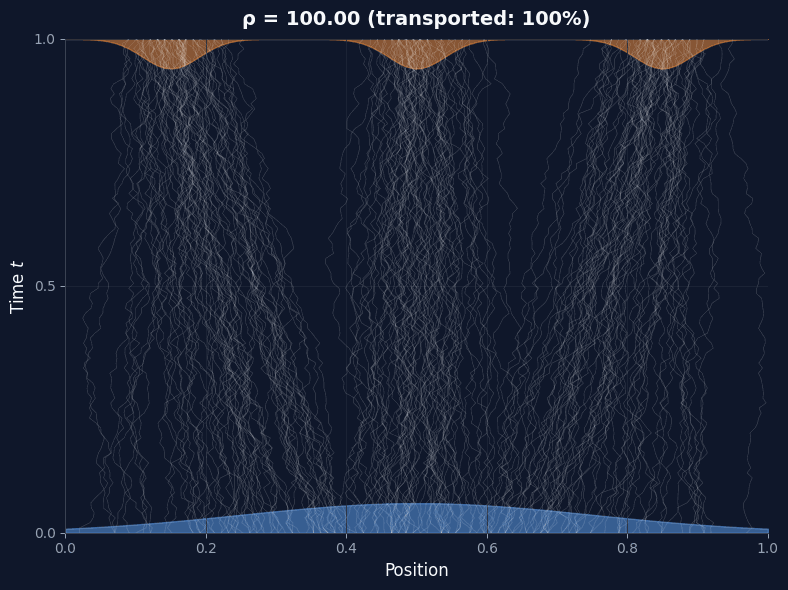

In [9]:
display_gif("../assets/ot_anim.gif")

## Key Takeaways

- **Schrödinger bridge = entropy-regularized OT**: the ε parameter controls the noise
  level of the stochastic bridge connecting two distributions
- **Particle trajectories reveal dynamics**: Brownian bridge paths show the transition
  from deterministic transport (straight lines) to diffusion (random walks)
- **Unbalanced OT via KL penalties**: the ρ parameter controls mass conservation,
  allowing birth-death processes — naturally modeled with exponential cones
- **CVXPY formulates, Moreau solves**: `cp.entr` and `cp.kl_div` express the entropy
  and KL terms; CVXPY reduces them to exponential cones, Moreau solves the conic program
- **cvxpylayers enables parametric sweeps**: wrapping each formulation as a differentiable
  PyTorch layer lets us batch over ε or ρ — compiled once, solved many times